**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [43]:
# Importing the required packages and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [44]:
# Loading in the Data
df = pd.read_csv("cars_hw.csv")
# Removing first column which is just an index
df = df.iloc[:,1:]
df.head()

,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


Question 1 (Data Cleaning)

In [53]:
# Originally included this code, but I realized a later question asks specifically what brand is most expensive,
# so putting them into 'Other' isn't actually helpful right now.

# Fixing Make column
# Creating a list of Years to categorize into each
# keep_make = ['Hyundai','Maruti Suzuki','Honda','Renault','Ford','Toyota','Volkswagen']

# Categorizing Make_Year into three categories
# df['Make'] = df['Make'].apply(lambda x: "Other" if x not in keep_make else x)

In [46]:
# Fixing Make_Year column
# Creating a list of Years to categorize into each
years_2011_to_2014 = [2011,2012,2013,2014]
years_2015_to_2019 = [2015,2016,2017,2018]
years_2020_to_2022 = [2019,2020,2021,2022]
# Categorizing Make_Year into three categories
df['Make_Year'] = df['Make_Year'].apply(lambda x: "2011-2014" if x in years_2011_to_2014 else x)
df['Make_Year'] = df['Make_Year'].apply(lambda x: "2015-2019" if x in years_2015_to_2019 else x)
df['Make_Year'] = df['Make_Year'].apply(lambda x: "2020-2022" if x in years_2020_to_2022 else x)

In [47]:
# Fixing Color column
# Creating a list of Colors to categorize into each
grey = ['grey','silver']
keep_colors = ['white','red','grey','blue']
# Categorizing Color into five categories
df['Color'] = df['Color'].apply(lambda x: 'grey' if x in grey else x)
df['Color'] = df['Color'].apply(lambda x: 'other' if x not in keep_colors else x)

In [48]:
# Fixing No_of_Owners column
two_or_more = ['2nd','3rd']
df['No_of_Owners'] = df['No_of_Owners'].apply(lambda x: '2nd+3rd' if x in two_or_more else x)

In [49]:
# Fixing Fuel_Type column
df['Fuel_Type'] = df['Fuel_Type'].apply(lambda x: 'petrol' if x == "petrol+cng" else x)

In [50]:
# Fixing Transmission column
other = ['5-Speed','6-Speed']
df['Transmission'] = df['Transmission'].apply(lambda x: 'Other' if x not in other else x)

In [67]:
# Transforming Price with log function to fix outliers
df["Price"] = np.log(df["Price"])

In [68]:
df.head()

,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,Volkswagen,2015-2019,grey,sedan,44611,1st,5,diesel,Other,Automatic,13.395439
1,Hyundai,2015-2019,red,crossover,20305,1st,5,petrol,5-Speed,Manual,13.432785
2,Honda,2020-2022,white,suv,29540,2nd+3rd,5,petrol,5-Speed,Manual,13.583579
3,Renault,2015-2019,other,hatchback,35680,1st,5,petrol,5-Speed,Manual,12.933621
4,Hyundai,2015-2019,other,hatchback,25126,1st,5,petrol,5-Speed,Manual,13.151922


In [69]:
df["Mileage_Run"].describe()

count      976.000000
mean     41571.195697
std      24390.995134
min       1117.000000
25%      22676.750000
50%      37570.500000
75%      57421.250000
max      99495.000000
Name: Mileage_Run, dtype: float64

Question 2

In [70]:
df["Price"].describe()

count    976.000000
mean      13.411033
std        0.450276
min       12.144197
25%       13.072647
50%       13.409795
75%       13.691080
max       14.894260
Name: Price, dtype: float64

<AxesSubplot:xlabel='Price', ylabel='Density'>

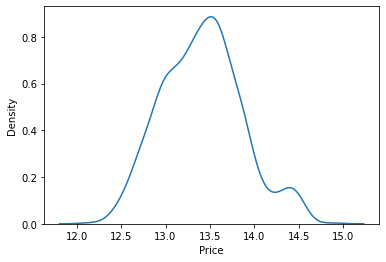

In [71]:
# kdeplot of Price
sns.kdeplot(data=df, x="Price")

In [72]:
# Calculating 
make_price_info = df.iloc[:,[0,10]].groupby('Make').describe()

In [73]:
make_price_info

Price                                                        \
               count       mean       std        min        25%        50%   
Make                                                                         
Chevrolet        6.0  12.919895  0.480975  12.495004  12.568392  12.752286   
Datsun           3.0  12.576047  0.036311  12.538967  12.558302  12.577636   
Ford            52.0  13.468280  0.210895  12.577636  13.361380  13.469493   
Honda           73.0  13.536318  0.336972  12.663497  13.272506  13.573439   
Hyundai        305.0  13.368511  0.398781  12.421184  13.091904  13.366094   
Jeep             4.0  14.216591  0.105084  14.070153  14.183270  14.240265   
Kia              8.0  14.292177  0.076877  14.129591  14.272242  14.303105   
MG Motors       35.0  14.439052  0.066263  14.278615  14.395744  14.429615   
Mahindra        18.0  13.898953  0.159906  13.587354  13.851808  13.905680   
Maruti Suzuki  293.0  13.218132  0.371409  12.375815  12.926348  13.174956   
Nissan           4.0  13.641194  0.392610  13.071070  13.537775  13.788723   
Renault         68.0  13.350862  0.331717  12.567237  13.071063  13.375395   
Skoda            5.0  13.640864  0.827046  12.985398  13.051941  13.195614   
Tata            23.0  13.713405  0.615090  12.144197  13.566383  13.675098   
Toyota          50.0  13.535507  0.360112  12.815838  13.171414  13.703461   
Volkswagen      29.0  13.294742  0.203839  12.904207  13.203021  13.316284   

                                     
                     75%        max  
Make                                 
Chevrolet      13.171681  13.701221  
Datsun         12.594587  12.611538  
Ford           13.575984  13.879424  
Honda          13.726679  14.245343  
Hyundai        13.637579  14.370544  
Jeep           14.273586  14.315680  
Kia            14.349515  14.369970  
MG Motors      14.497597  14.518113  
Mahindra       13.961249  14.197366  
Maruti Suzuki  13.546323  13.966513  
Nissan         13.892143  13.916260  
Renault        13.593607  13.967373  
Skoda          14.077105  14.894260  
Tata           14.251370  14.557448  
Toyota         13.838227  13.903521  
Volkswagen     13.457406  13.579788

<AxesSubplot:xlabel='Price', ylabel='Density'>

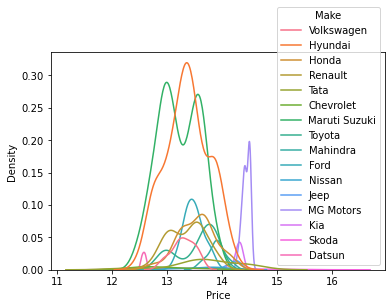

In [74]:
# kdeplot of Price, grouped by Make
sns.kdeplot(data=df,x='Price',hue='Make')

The most expensive car brand looks like MG Motors. Prices are generally spiked around 50,000-70,000 for most of the car brands.

Question 3 & 4

In [120]:
def split(df, features, target):
    # Selecting features and preparing arrays for split
    X = df[features].dropna()
    
    # use the same target variable, but drop rows with missing features
    y = df.loc[X.index, target]
    
    # Training and testing data split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
    
    # Creating Linear Regression model on the training data
    model = LinearRegression().fit(X_train, y_train)
    
    # Predicting values to calculate RMSE
    y_pred = model.predict(X_test)
    
    # Calculate and print RMSE and R²
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"R Squared Error: {r2}\nRoot Mean Squared Error: {rmse}")
    return y_pred, y_test

In [121]:
pred, test = split(df=df, features=['Mileage_Run','Seating_Capacity'], target='Price')

R Squared Error: 0.025006631759868836
Root Mean Squared Error: 0.43916654719835346


In [115]:
# One-hot encoding - need to drop first column to avoid multicollinearity this time
to_cat = list(df.select_dtypes('object'))
df_encoded = pd.get_dummies(df, columns = to_cat, drop_first = True)

In [116]:
df_encoded.columns

Index(['Mileage_Run', 'Seating_Capacity', 'Price', 'Make_Datsun', 'Make_Ford',
       'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Make_Year_2015-2019', 'Make_Year_2020-2022', 'Color_grey',
       'Color_other', 'Color_red', 'Color_white', 'Body_Type_hatchback',
       'Body_Type_muv', 'Body_Type_sedan', 'Body_Type_suv',
       'No_of_Owners_2nd+3rd', 'Fuel_Type_petrol', 'Transmission_6-Speed',
       'Transmission_Other', 'Transmission_Type_Manual'],
      dtype='object')

In [122]:
# This is not pretty but it works
pred2, test2 = split(df=df_encoded, features=['Make_Datsun', 'Make_Ford',
       'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Make_Year_2015-2019', 'Make_Year_2020-2022', 'Color_grey',
       'Color_other', 'Color_red', 'Color_white', 'Body_Type_hatchback',
       'Body_Type_muv', 'Body_Type_sedan', 'Body_Type_suv',
       'No_of_Owners_2nd+3rd', 'Fuel_Type_petrol', 'Transmission_6-Speed',
       'Transmission_Other', 'Transmission_Type_Manual'], target='Price')

R Squared Error: 0.7511785422438493
Root Mean Squared Error: 0.22185659090130708


The second model performs better with a much higher r squared error value and a lower RMSE value meaning that the predicted value is not as different from the true value as the first model.

In [123]:
best_y_pred, best_y_test = split(df=df_encoded, features=['Mileage_Run','Seating_Capacity','Make_Datsun', 'Make_Ford',
       'Make_Honda', 'Make_Hyundai', 'Make_Jeep', 'Make_Kia', 'Make_MG Motors',
       'Make_Mahindra', 'Make_Maruti Suzuki', 'Make_Nissan', 'Make_Renault',
       'Make_Skoda', 'Make_Tata', 'Make_Toyota', 'Make_Volkswagen',
       'Make_Year_2015-2019', 'Make_Year_2020-2022', 'Color_grey',
       'Color_other', 'Color_red', 'Color_white', 'Body_Type_hatchback',
       'Body_Type_muv', 'Body_Type_sedan', 'Body_Type_suv',
       'No_of_Owners_2nd+3rd', 'Fuel_Type_petrol', 'Transmission_6-Speed',
       'Transmission_Other', 'Transmission_Type_Manual'], target='Price')

R Squared Error: 0.7691520290634372
Root Mean Squared Error: 0.21369356825987285


This third model is even more accurate than the first two models with an improved r squared error of about 1.8% and a lower RMSE by about 0.8.

Question 5

In [112]:
results = {}
for degree in range(1,10):
    # Choosing features
    X_poly_base = df[['Mileage_Run','Seating_Capacity']].dropna()
    y_poly = df.loc[X_poly_base.index, 'Price']
    
    # Changes degree according to list
    pf = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = pf.fit_transform(X_poly_base)
    
    # Fit linear, degree-2, and degree-3 models on the same feature
    X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly_base, y_poly, test_size=0.2, random_state=42)

    # Polynomial fitting
    Xtr = pf.fit_transform(X_train_p)
    Xte = pf.transform(X_test_p)
    m   = LinearRegression().fit(Xtr, y_train_p)
    
    # Calculating RMSE
    y_pred_p = m.predict(Xte)
    mse = mean_squared_error(y_test_p, y_pred_p)
    rmse = np.sqrt(mse)

    # Calculating R squared error
    r2  = m.score(Xte, y_test_p)
    results[f'degree_{degree}'] = r2
    print(f"Degree {degree}  |  Test R²: {r2:.4f}  |  Test RMSE: {rmse:.4f}")

Degree 1  |  Test R²: 0.0821  |  Test RMSE: 0.4184
Degree 2  |  Test R²: 0.0652  |  Test RMSE: 0.4222
Degree 3  |  Test R²: 0.0767  |  Test RMSE: 0.4196
Degree 4  |  Test R²: 0.0569  |  Test RMSE: 0.4241
Degree 5  |  Test R²: 0.0599  |  Test RMSE: 0.4234
Degree 6  |  Test R²: 0.0577  |  Test RMSE: 0.4239
Degree 7  |  Test R²: 0.0476  |  Test RMSE: 0.4262
Degree 8  |  Test R²: 0.0248  |  Test RMSE: 0.4312
Degree 9  |  Test R²: -0.0078  |  Test RMSE: 0.4384


As the degree of the polynomial features increases, the R squared error decreases, but the RMSE actually increases. R squared error goes negative at 9 degrees. The best model is still the linear model with degree 1, however the polynomial model with degree 3 is also strong. The model's are not better than in previous parts, especially with a far lower r squared error.

Question 6

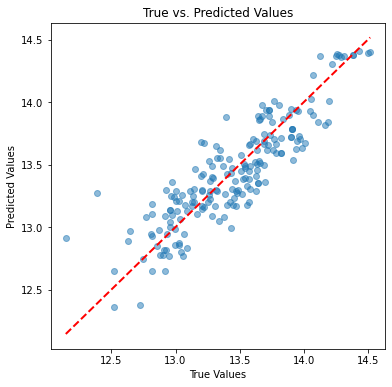

In [126]:
# True vs. Predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(best_y_test, best_y_pred, alpha=0.5)
plt.plot([best_y_test.min(), best_y_test.max()], [best_y_test.min(), best_y_test.max()], 'r--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs. Predicted Values')
plt.show()

In [130]:
# Calculating residuals of the data
residuals = best_y_test - best_y_pred

<AxesSubplot:xlabel='Price', ylabel='Density'>

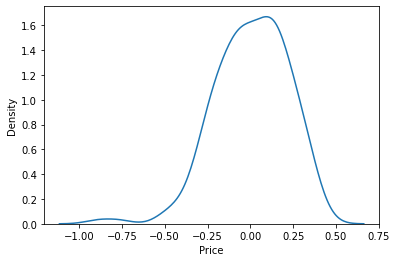

In [132]:
# Graphing kdeplot of residuals
sns.kdeplot(data=df, x=residuals)

The bell curve is roughly around 0, however there are clearly negative values which shows the model has some issue predicting outliers in that direction. However, the model is strong at predicting most values that fall within the central linear regression line.